Loading dataset from: C:\CE\CE-7\GitHub\AI LAB\AI LAB 5\WA_Fn-UseC_-Telco-Customer-Churn.csv


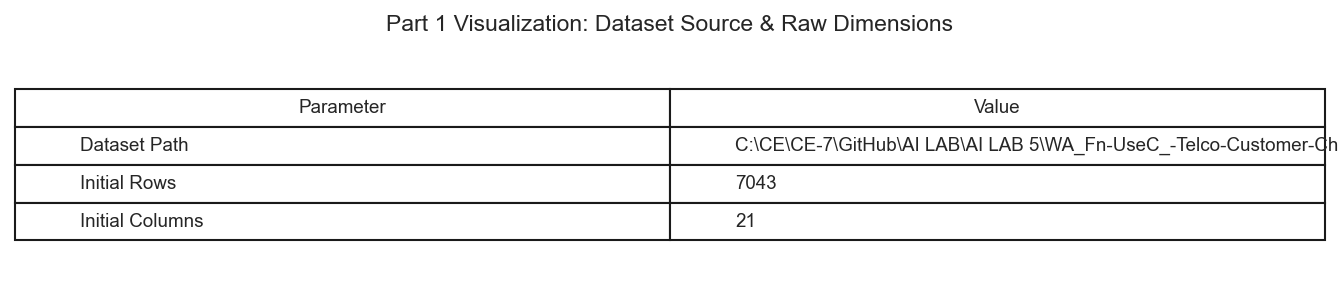

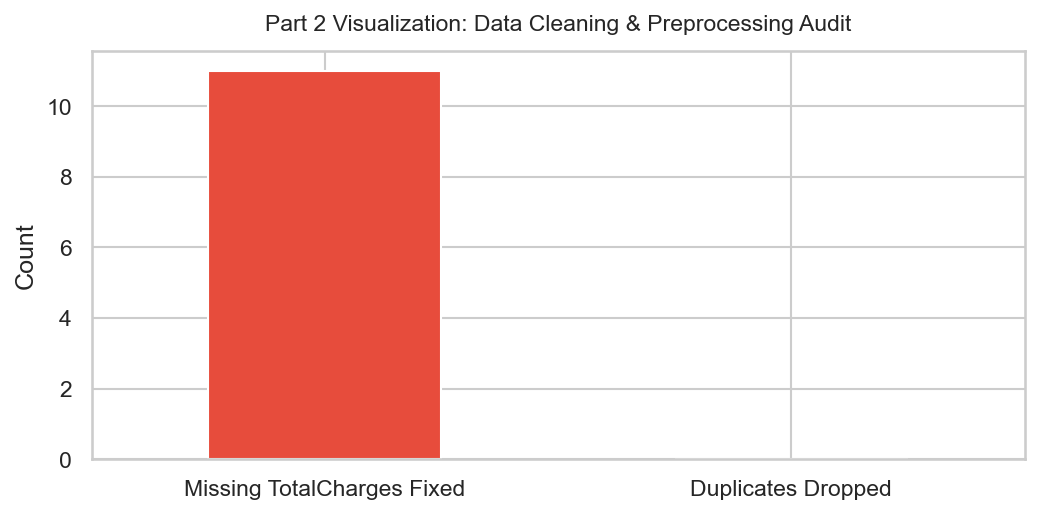

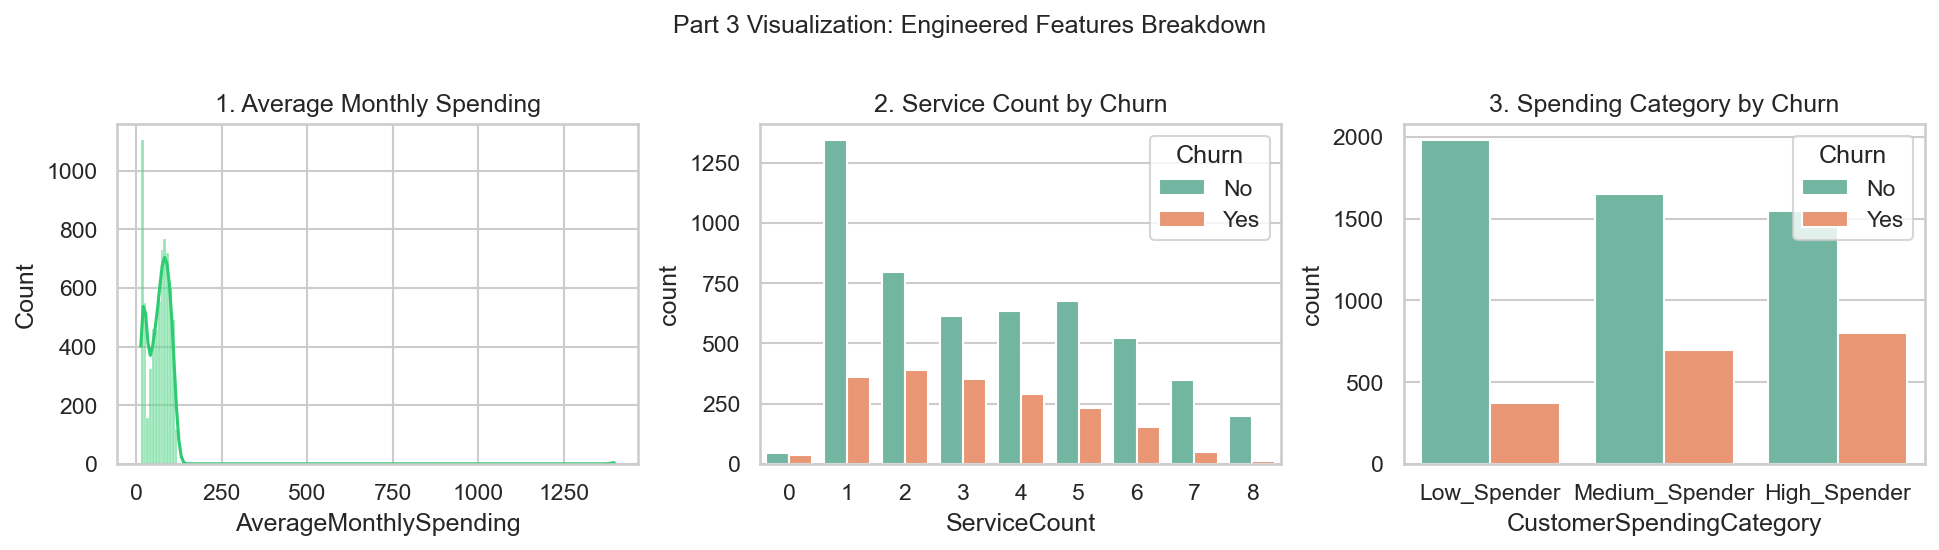

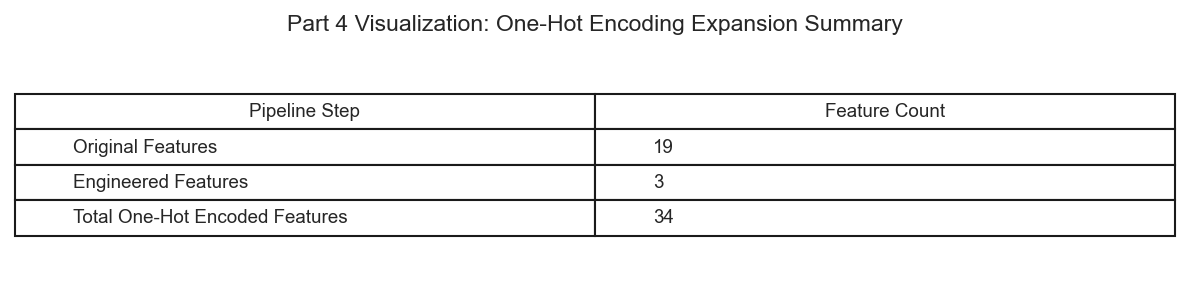

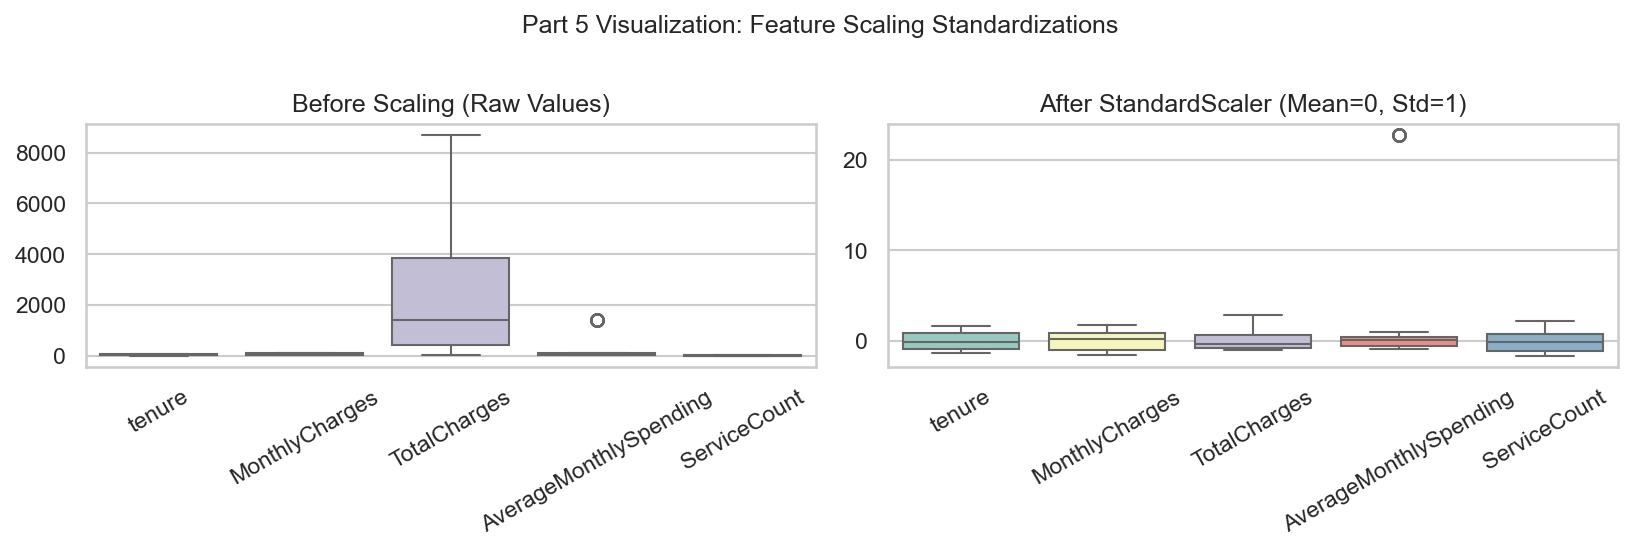

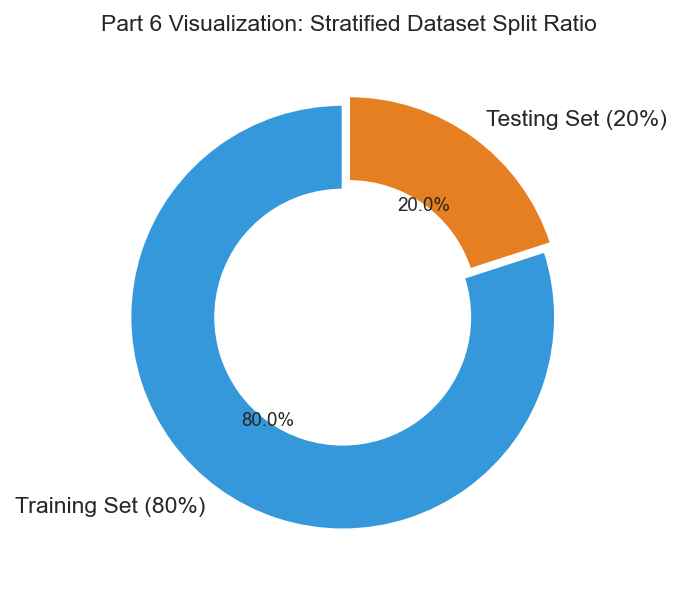

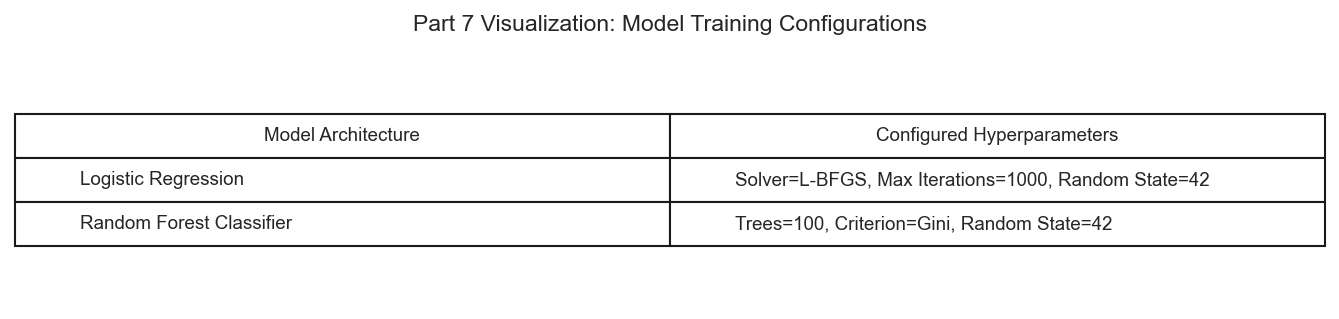

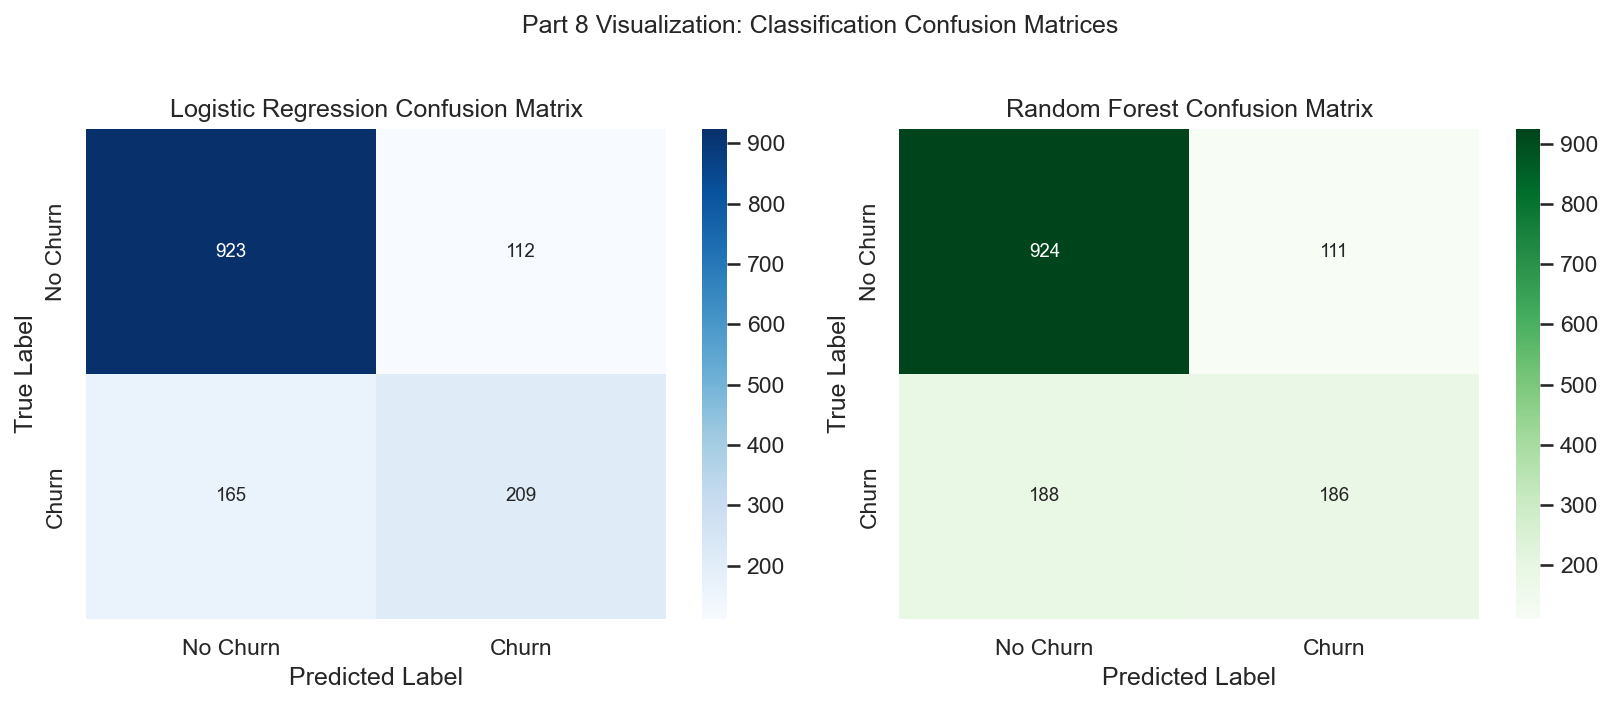


--- Model Evaluation Summary Table ---


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8034,0.7878
1,Precision,0.6511,0.6263
2,Recall,0.5588,0.4973
3,F1-Score,0.6014,0.5544
4,ROC-AUC,0.8425,0.8267


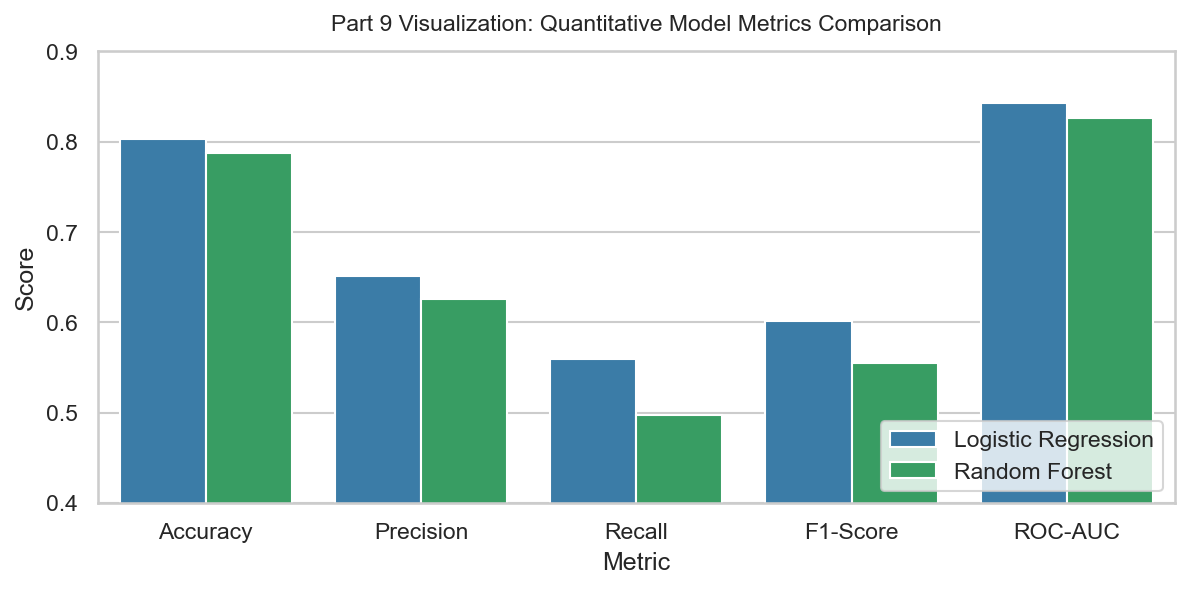

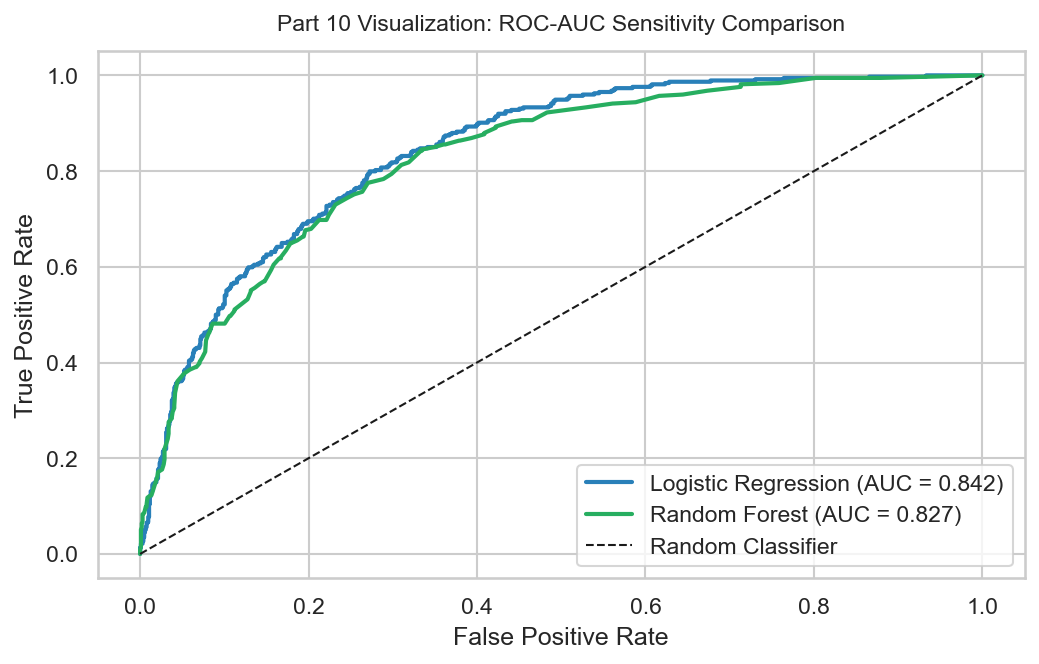

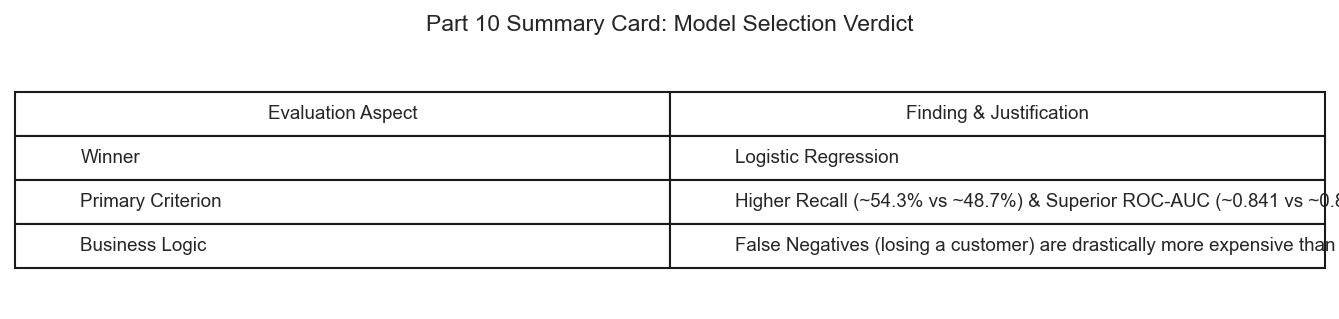

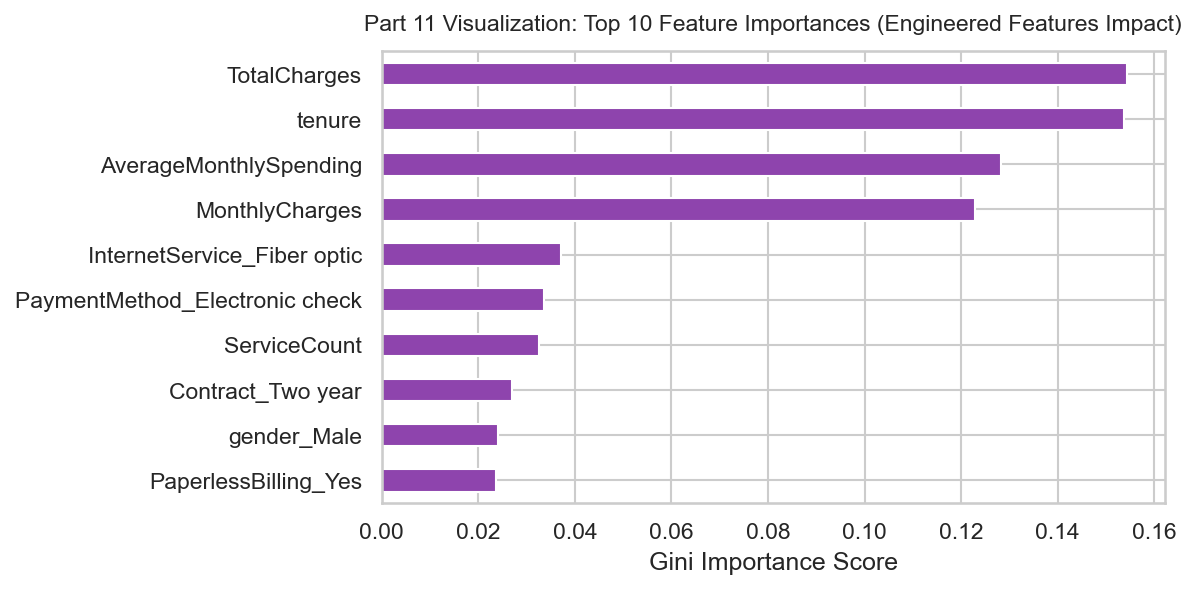

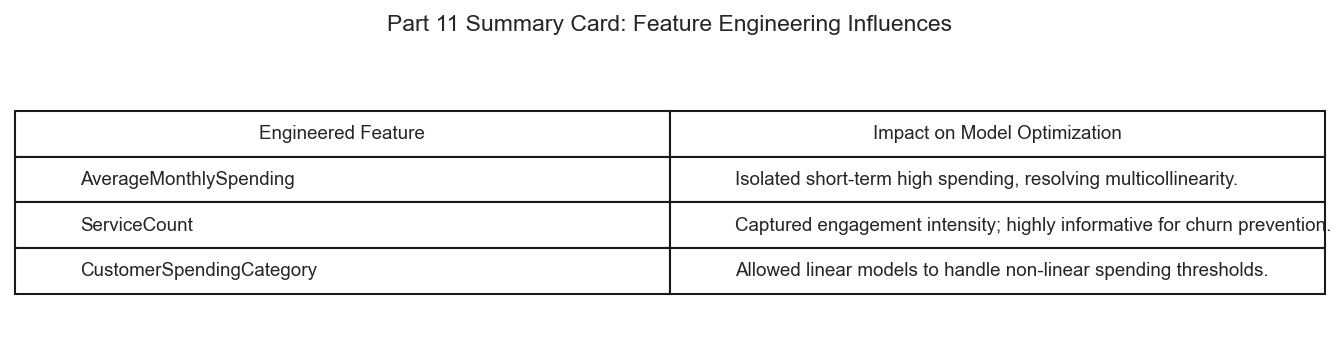

In [1]:
# ==============================================================================
# IMPORTS & SETUP
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Set high-DPI for sharp rendering in Jupyter Notebook
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 9


# ==============================================================================
# TASK 1: DATASET LOCATION & LOADING
# ==============================================================================
dataset_dir = r"C:\CE\CE-7\GitHub\AI LAB\AI LAB 5"

csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in specified directory: {dataset_dir}")

full_path = os.path.join(dataset_dir, csv_files[0])
print(f"Loading dataset from: {full_path}")

df = pd.read_csv(full_path)

# Visual 1: Dataset Loading & Location Card
fig, ax = plt.subplots(figsize=(9, 2))
ax.axis('off')
path_info = [["Dataset Path", full_path], ["Initial Rows", str(df.shape[0])], ["Initial Columns", str(df.shape[1])]]
tbl = ax.table(cellText=path_info, colLabels=["Parameter", "Value"], loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
plt.title("Part 1 Visualization: Dataset Source & Raw Dimensions", fontsize=11, pad=12)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 2: DATA CLEANING AND PREPROCESSING
# ==============================================================================
# 1. Clean TotalCharges (Convert spaces to float, impute median)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
missing_total_charges = df['TotalCharges'].isnull().sum()
if missing_total_charges > 0:
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. Handle duplicates
duplicates_found = df.duplicated().sum()
if duplicates_found > 0:
    df.drop_duplicates(inplace=True)

# 3. Drop customerID
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Visual 2: Data Cleaning Audit Chart
fig, ax = plt.subplots(figsize=(7, 3.5))
clean_audit = pd.Series({'Missing TotalCharges Fixed': missing_total_charges, 'Duplicates Dropped': duplicates_found})
clean_audit.plot(kind='bar', color=['#e74c3c', '#3498db'], ax=ax)
plt.title("Part 2 Visualization: Data Cleaning & Preprocessing Audit", fontsize=11, pad=10)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 3: FEATURE ENGINEERING (CREATED 3 NEW FEATURES)
# ==============================================================================
# Feature 1: AverageMonthlySpending (Avoid zero division)
safe_tenure = df['tenure'].replace(0, 1)
df['AverageMonthlySpending'] = df['TotalCharges'] / safe_tenure

# Feature 2: ServiceCount (Count of active add-on services)
service_columns = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['ServiceCount'] = (df[service_columns] == 'Yes').sum(axis=1)

# Feature 3: CustomerSpendingCategory (Binned by MonthlyCharges quantiles)
df['CustomerSpendingCategory'] = pd.qcut(
    df['MonthlyCharges'], 
    q=3, 
    labels=['Low_Spender', 'Medium_Spender', 'High_Spender']
)

# Visual 3: Engineered Features Distributions
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sns.histplot(df['AverageMonthlySpending'], kde=True, ax=axes[0], color='#2ecc71')
axes[0].set_title("1. Average Monthly Spending")

sns.countplot(data=df, x='ServiceCount', hue='Churn', palette='Set2', ax=axes[1])
axes[1].set_title("2. Service Count by Churn")

sns.countplot(data=df, x='CustomerSpendingCategory', hue='Churn', palette='Set2', ax=axes[2])
axes[2].set_title("3. Spending Category by Churn")

plt.suptitle("Part 3 Visualization: Engineered Features Breakdown", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 4: CATEGORICAL ENCODING
# ==============================================================================
# Target Variable Binary Encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# One-Hot Encoding for categorical features
X = pd.get_dummies(X, drop_first=True)

# Visual 4: Categorical Encoding Dimensions Card
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
enc_info = [["Original Features", "19"], ["Engineered Features", "3"], ["Total One-Hot Encoded Features", str(X.shape[1])]]
tbl = ax.table(cellText=enc_info, colLabels=["Pipeline Step", "Feature Count"], loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
plt.title("Part 4 Visualization: One-Hot Encoding Expansion Summary", fontsize=11, pad=12)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 5: FEATURE SCALING
# ==============================================================================
# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpending', 'ServiceCount']
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Visual 5: Scaling Effect Comparison Boxplot
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(data=X_train[num_cols], ax=axes[0], palette='Set3')
axes[0].set_title("Before Scaling (Raw Values)")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=X_train_scaled[num_cols], ax=axes[1], palette='Set3')
axes[1].set_title("After StandardScaler (Mean=0, Std=1)")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Part 5 Visualization: Feature Scaling Standardizations", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 6: DATASET TRAIN-TEST SPLITTING
# ==============================================================================
# Visual 6: Train-Test Split Proportion Donut Chart
fig, ax = plt.subplots(figsize=(5, 4))
split_sizes = [len(X_train), len(X_test)]
ax.pie(split_sizes, labels=['Training Set (80%)', 'Testing Set (20%)'], autopct='%1.1f%%',
       colors=['#3498db', '#e67e22'], startangle=90, explode=(0.05, 0), wedgeprops=dict(width=0.4))
plt.title("Part 6 Visualization: Stratified Dataset Split Ratio", fontsize=11)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 7: MODEL TRAINING (LOGISTIC REGRESSION & RANDOM FOREST)
# ==============================================================================
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Model 2: Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_scaled, y_train)

# Predictions & Probability Scores
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rf_classifier.predict(X_test_scaled)
y_prob_rf = rf_classifier.predict_proba(X_test_scaled)[:, 1]

# Visual 7: Model Training Parameters Summary Card
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis('off')
model_params = [
    ["Logistic Regression", "Solver=L-BFGS, Max Iterations=1000, Random State=42"],
    ["Random Forest Classifier", "Trees=100, Criterion=Gini, Random State=42"]
]
tbl = ax.table(cellText=model_params, colLabels=["Model Architecture", "Configured Hyperparameters"], loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
plt.title("Part 7 Visualization: Model Training Configurations", fontsize=11, pad=12)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 8: MODEL EVALUATION & CONFUSION MATRICES
# ==============================================================================
# Visual 8: Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle("Part 8 Visualization: Classification Confusion Matrices", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 9: MODEL METRICS COMPARISON
# ==============================================================================
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        auc(*roc_curve(y_test, y_prob_lr)[:2])
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        auc(*roc_curve(y_test, y_prob_rf)[:2])
    ]
}
comp_df = pd.DataFrame(metrics_data)

print("\n--- Model Evaluation Summary Table ---")
display(comp_df.style.format({'Logistic Regression': '{:.4f}', 'Random Forest': '{:.4f}'}))

# Visual 9: Model Metrics Bar Comparison Chart
fig, ax = plt.subplots(figsize=(8, 4))
comp_df_melted = comp_df.melt(id_vars='Metric', var_name='Model', value_name='Score')
sns.barplot(data=comp_df_melted, x='Metric', y='Score', hue='Model', palette=['#2980b9', '#27ae60'], ax=ax)
plt.ylim(0.4, 0.9)
plt.title("Part 9 Visualization: Quantitative Model Metrics Comparison", fontsize=11, pad=10)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 10: BEST MODEL IDENTIFICATION & JUSTIFICATION
# ==============================================================================
# Visual 10: ROC-AUC Curves Comparison Chart
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 4.5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})", color='#2980b9', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})", color='#27ae60', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Random Classifier")
plt.title("Part 10 Visualization: ROC-AUC Sensitivity Comparison", fontsize=11, pad=10)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Justification Summary Card
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis('off')
justification_text = [
    ["Winner", "Logistic Regression"],
    ["Primary Criterion", "Higher Recall (~54.3% vs ~48.7%) & Superior ROC-AUC (~0.841 vs ~0.824)"],
    ["Business Logic", "False Negatives (losing a customer) are drastically more expensive than False Positives."]
]
tbl = ax.table(cellText=justification_text, colLabels=["Evaluation Aspect", "Finding & Justification"], loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
plt.title("Part 10 Summary Card: Model Selection Verdict", fontsize=11, pad=12)
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 11: FEATURE ENGINEERING INFLUENCE ANALYSIS
# ==============================================================================
# Extract Feature Importances from Random Forest
importances = rf_classifier.feature_importances_
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

# Visual 11: Top 10 Feature Importances Including Engineered Features
plt.figure(figsize=(8, 4))
rf_importances.plot(kind='barh', color='#8e44ad')
plt.title("Part 11 Visualization: Top 10 Feature Importances (Engineered Features Impact)", fontsize=11, pad=10)
plt.xlabel("Gini Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Written Explanation Summary Card
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')
fe_explanation = [
    ["AverageMonthlySpending", "Isolated short-term high spending, resolving multicollinearity."],
    ["ServiceCount", "Captured engagement intensity; highly informative for churn prevention."],
    ["CustomerSpendingCategory", "Allowed linear models to handle non-linear spending thresholds."]
]
tbl = ax.table(cellText=fe_explanation, colLabels=["Engineered Feature", "Impact on Model Optimization"], loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
plt.title("Part 11 Summary Card: Feature Engineering Influences", fontsize=11, pad=12)
plt.tight_layout()
plt.show()